In [1]:
import os
import gc
import json
import random
import psutil
import ast
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
MODEL_ID  = "HuggingFaceTB/SmolVLM-500M-Instruct"
LOG_DIR   = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(ast.literal_eval)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Show expanded dataset size
total_train_examples = train_df["num_choices"].sum()
print(f"Expanded train examples (one per choice): {total_train_examples:,}")

Train: 3,109 | Val: 1,048 | Test: 1,008
Expanded train examples (one per choice): 9,666


In [3]:
def build_nli_prompt(row, choice_text, include_answer=False, max_context_chars=2000):
    """Build a Yes/No NLI prompt for a single choice."""
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"
    text += f"Question: {row['question']}\n"
    text += f"Proposed answer: {choice_text}\n"
    text += "Is this the correct answer? Yes or No."

    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"

    if include_answer:
        prompt += " Yes" if include_answer == "yes" else " No"

    return prompt

# Verify
sample = train_df.iloc[0]
for j, choice in enumerate(sample["choices"]):
    is_correct = (j == int(sample["answer"]))
    target     = "yes" if is_correct else "no"
    prompt     = build_nli_prompt(sample, choice, include_answer=target)
    print(f"Choice {chr(65+j)} ({'CORRECT' if is_correct else 'wrong'}): ends with '{prompt[-10:]}'")

Choice A (wrong): ends with 'istant: No'
Choice B (wrong): ends with 'istant: No'
Choice C (CORRECT): ends with 'stant: Yes'


In [4]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

processor.image_processor.do_image_splitting = False
processor.image_processor.size              = {"longest_edge": 512}
processor.image_processor.max_image_size    = {"longest_edge": 512}

# Get Yes/No token ids
yes_token = processor.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
no_token  = processor.tokenizer("No",  add_special_tokens=False)["input_ids"][0]
print(f"'Yes' token id: {yes_token}")
print(f"'No'  token id: {no_token}")
print(f"do_image_splitting: {processor.image_processor.do_image_splitting}")
print(f"size: {processor.image_processor.size}")

'Yes' token id: 10539
'No'  token id: 5230
do_image_splitting: False
size: {'longest_edge': 512}


In [5]:
class NLIDataset(Dataset):
    """
    Expands each sample into N examples — one per choice.
    Correct choice → target "Yes", incorrect → target "No".
    """
    def __init__(self, df, data_dir, max_context_chars=2000):
        self.data_dir         = data_dir
        self.max_context_chars = max_context_chars
        self.examples         = []

        for _, row in df.iterrows():
            img_path = data_dir / row["image_path"]
            for j, choice in enumerate(row["choices"]):
                is_correct = (j == int(row["answer"]))
                self.examples.append({
                    "image_path": img_path,
                    "prompt":     build_nli_prompt(
                                      row, choice,
                                      include_answer="yes" if is_correct else "no",
                                      max_context_chars=max_context_chars
                                  ),
                    "label":      1 if is_correct else 0,
                })

        print(f"NLIDataset: {len(self.examples):,} examples from {len(df):,} samples")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex  = self.examples[idx]
        img = Image.open(ex["image_path"]).convert("RGB")
        return {
            "image":  img,
            "text":   ex["prompt"],
            "label":  ex["label"],
        }

train_nli_ds = NLIDataset(train_df, DATA_DIR)
print(f"\nSample breakdown:")
labels = [ex["label"] for ex in train_nli_ds.examples]
print(f"  Yes (correct): {sum(labels):,}")
print(f"  No (incorrect): {len(labels) - sum(labels):,}")

NLIDataset: 9,666 examples from 3,109 samples

Sample breakdown:
  Yes (correct): 3,109
  No (incorrect): 6,557


In [6]:
# Find assistant token ids for loss masking
assistant_token_ids = processor.tokenizer(
    "Assistant:", add_special_tokens=False
)["input_ids"]
print(f"'Assistant:' token ids: {assistant_token_ids}")

def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    labels  = [b["label"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    # Mask everything before and including "Assistant:" — only train on Yes/No
    loss_labels = inputs["input_ids"].clone()
    loss_labels[loss_labels == processor.tokenizer.pad_token_id] = -100

    for i in range(loss_labels.shape[0]):
        seq   = inputs["input_ids"][i].tolist()
        found = False
        for pos in range(len(seq) - len(assistant_token_ids)):
            if seq[pos:pos + len(assistant_token_ids)] == assistant_token_ids:
                loss_labels[i, :pos + len(assistant_token_ids)] = -100
                found = True
                break
        if not found:
            loss_labels[i, :] = -100

    inputs["labels"] = loss_labels
    return inputs, torch.tensor(labels)

# Verify masking
sample_batch = [train_nli_ds[i] for i in range(4)]
inputs_test, labels_test = collate_fn(sample_batch)
for i in range(4):
    label_ids  = inputs_test["labels"][i]
    valid_mask = label_ids != -100
    valid_ids  = label_ids[valid_mask]
    decoded    = processor.tokenizer.decode(valid_ids)
    print(f"Sample {i+1} | label={labels_test[i].item()} | trained on: '{decoded}'")

def score_choices_nli(model, processor, image, row, choices, max_context_chars=2000):
    """Score each choice with Yes/No logit difference."""
    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, include_answer=False,
                                  max_context_chars=max_context_chars)
        inputs = processor(
            text=[prompt], images=[image],
            return_tensors="pt", padding=True
        )
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]

        score = logits[0, yes_token].item() - logits[0, no_token].item()
        scores.append(score)

        del outputs, logits, inputs
        torch.cuda.empty_cache()

    return int(torch.tensor(scores).argmax().item())

'Assistant:' token ids: [9519, 9531, 42]
Sample 1 | label=0 | trained on: ' No'
Sample 2 | label=0 | trained on: ' No'
Sample 3 | label=1 | trained on: ' Yes'
Sample 4 | label=1 | trained on: ' Yes'


In [7]:
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134
RAM:  6.9/16.7 GB
VRAM: 0.42 GB


In [8]:
def evaluate(model, val_df, data_dir, n_samples=500, seed=42):
    model.eval()
    subset  = val_df.sample(min(n_samples, len(val_df)), random_state=seed).reset_index(drop=True)
    correct = 0

    for idx in tqdm(range(len(subset)), desc="Val eval"):
        row   = subset.iloc[idx]
        image = Image.open(data_dir / row["image_path"]).convert("RGB")
        pred  = score_choices_nli(model, processor, image, row, row["choices"])
        if pred == int(row["answer"]):
            correct += 1

    acc = correct / len(subset)
    print(f"Val accuracy ({len(subset)} samples): {acc:.4f}")
    model.train()
    return acc

Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 1 | avg loss: 0.4079
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.7900
Epoch 1 | val accuracy: 0.7900
Saved: logs/nli_ckpt_epoch1_20260429_101700
RAM: 7.6/16.7 GB | VRAM: 0.48 GB


Epoch 2:   0%|          | 0/2417 [00:00<?, ?it/s]

...

Val accuracy (500 samples): 0.8980
Epoch 4 | val accuracy: 0.8980
Saved: logs/nli_ckpt_epoch4_20260429_101700
RAM: 7.6/16.7 GB | VRAM: 0.48 GB


Epoch 5:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 5 | avg loss: 0.0504
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.9020
Epoch 5 | val accuracy: 0.9020
Saved: logs/nli_ckpt_epoch5_20260429_101700
RAM: 7.6/16.7 GB | VRAM: 0.48 GB


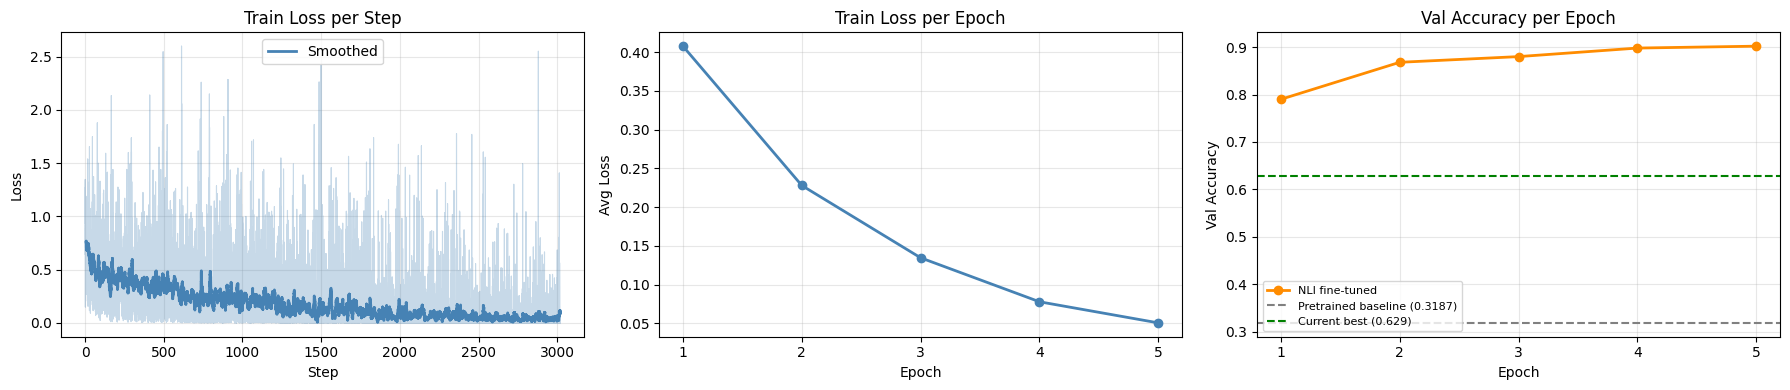


── Summary ──────────────────────────────────────────────
Epoch    Avg Loss     Val Accuracy
-----------------------------------
1        0.4079       0.7900
2        0.2280       0.8680
3        0.1345       0.8800
4        0.0777       0.8980
5        0.0504       0.9020

Best val accuracy: 0.9020 at epoch 5
Training complete.


In [9]:
from bitsandbytes.optim import PagedAdamW8bit
from transformers import get_cosine_schedule_with_warmup

EPOCHS       = 5
BATCH_SIZE   = 4
GRAD_ACCUM   = 4
LR           = 2e-4
WARMUP_RATIO = 0.03

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id":                 run_id,
    "hyperparameters": {
        "epochs":             EPOCHS,
        "batch_size":         BATCH_SIZE,
        "grad_accum":         GRAD_ACCUM,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
        "lr":                 LR,
        "lora_r":             16,
        "lora_alpha":         32,
        "target_modules":     ["q_proj", "k_proj", "v_proj", "o_proj"],
        "loss":               "NLI_yes_no",
        "max_context_chars":  2000,
    },
    "train_loss_per_step":    [],
    "train_loss_per_epoch":   [],
    "val_accuracy_per_epoch": [],
    "baseline_leaderboard":   0.629,
}

train_loader = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

optimizer    = PagedAdamW8bit(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

def plot_training(log):
    steps        = [s["step"] for s in log["train_loss_per_step"]]
    losses       = [s["loss"]  for s in log["train_loss_per_step"]]
    epoch_losses = log["train_loss_per_epoch"]
    val_accs     = log["val_accuracy_per_epoch"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(steps, losses, alpha=0.3, color="steelblue", linewidth=0.8)
    if len(losses) >= 30:
        smoothed = pd.Series(losses).rolling(30).mean()
        axes[0].plot(steps, smoothed, color="steelblue", linewidth=2, label="Smoothed")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Train Loss per Step")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses,
                 marker="o", color="steelblue", linewidth=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Loss")
    axes[1].set_title("Train Loss per Epoch")
    axes[1].set_xticks(range(1, EPOCHS+1)); axes[1].grid(alpha=0.3)

    axes[2].plot(range(1, len(val_accs)+1), val_accs,
                 marker="o", color="darkorange", linewidth=2, label="NLI fine-tuned")
    axes[2].axhline(y=0.3187, color="gray",  linestyle="--", label="Pretrained baseline (0.3187)")
    axes[2].axhline(y=0.629,  color="green", linestyle="--", label="Current best (0.629)")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val Accuracy")
    axes[2].set_title("Val Accuracy per Epoch")
    axes[2].set_xticks(range(1, EPOCHS+1))
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / f"nli_training_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Training loop ─────────────────────────────────────────────────────────────
global_step = 0
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    optimizer.zero_grad()

    for step, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        outputs = model(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        log["train_loss_per_step"].append({
            "step":  global_step,
            "epoch": epoch + 1,
            "loss":  outputs.loss.item(),
        })

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    # Val eval
    print("Running val eval...")
    val_acc = evaluate(model, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    model.train()

    # Save checkpoint
    ckpt_path = LOG_DIR / f"nli_ckpt_epoch{epoch+1}_{run_id}"
    model.save_pretrained(ckpt_path)
    torch.save({
        "epoch":                epoch + 1,
        "global_step":          global_step,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "log":                  log,
    }, LOG_DIR / f"nli_trainer_state_epoch{epoch+1}_{run_id}.pt")
    with open(LOG_DIR / f"nli_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# Final plots
plot_training(log)
with open(LOG_DIR / f"nli_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 35)
for i, (loss, acc) in enumerate(zip(log["train_loss_per_epoch"], log["val_accuracy_per_epoch"])):
    print(f"{i+1:<8} {loss:<12.4f} {acc:.4f}")
best_acc   = max(log["val_accuracy_per_epoch"])
best_epoch = log["val_accuracy_per_epoch"].index(best_acc) + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print("Training complete.")

In [10]:
# ── Generate test submissions from epochs 4 and 5 ─────────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

for EPOCH in [4, 5]:
    print(f"\n{'='*60}")
    print(f"Generating submission for epoch {EPOCH}")
    print(f"{'='*60}")

    CKPT_PATH = LOG_DIR / f"nli_ckpt_epoch{EPOCH}_{run_id}"
    print(f"Loading checkpoint: {CKPT_PATH}")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base, CKPT_PATH)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"Epoch {EPOCH} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name = f"submission_nli_epoch{EPOCH}_{run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved {sub_name}")
    print(f"Shape: {submission_df.shape}")

    del infer_model, base
    gc.collect()
    torch.cuda.empty_cache()

print("\nDone. Submit both files to Kaggle and compare leaderboard scores.")


Generating submission for epoch 4
Loading checkpoint: logs/nli_ckpt_epoch4_20260429_101700


Epoch 4 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_epoch4_20260429_101700.csv
Shape: (1008, 2)

Generating submission for epoch 5
Loading checkpoint: logs/nli_ckpt_epoch5_20260429_101700


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 5 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_epoch5_20260429_101700.csv
Shape: (1008, 2)

Done. Submit both files to Kaggle and compare leaderboard scores.


In [11]:
# ── Ensemble epochs 3 and 4 ───────────────────────────────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

ENSEMBLE_EPOCHS = [3, 4]
models = []

# Load all checkpoints
for epoch in ENSEMBLE_EPOCHS:
    ckpt_path = LOG_DIR / f"nli_ckpt_epoch{epoch}_{run_id}"
    print(f"Loading epoch {epoch} from {ckpt_path}...")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    m = PeftModel.from_pretrained(base, ckpt_path)
    m.eval()
    models.append(m)
    print(f"Loaded epoch {epoch}")

def score_choices_nli_ensemble(models, processor, image, row, choices, max_context_chars=2000):
    """Average Yes/No logit scores across all models."""
    final_scores = [0.0] * len(choices)

    for model in models:
        for j, choice in enumerate(choices):
            prompt = build_nli_prompt(row, choice, include_answer=False,
                                      max_context_chars=max_context_chars)
            inputs = processor(
                text=[prompt], images=[image],
                return_tensors="pt", padding=True
            )
            inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                      for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
                logits  = outputs.logits[:, -1, :]

            score = logits[0, yes_token].item() - logits[0, no_token].item()
            final_scores[j] += score  # accumulate across models

            del outputs, logits, inputs
            torch.cuda.empty_cache()

    # Average across models
    final_scores = [s / len(models) for s in final_scores]
    return int(torch.tensor(final_scores).argmax().item())

# ── Val eval with ensemble ────────────────────────────────────────────────────
print("\nRunning ensemble val eval (500 samples)...")
val_subset = val_df.sample(500, random_state=42).reset_index(drop=True)
correct = 0

for idx in tqdm(range(len(val_subset))):
    row   = val_subset.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred  = score_choices_nli_ensemble(models, processor, image, row, row["choices"])
    if pred == int(row["answer"]):
        correct += 1

ensemble_val_acc = correct / len(val_subset)
print(f"\nEnsemble val accuracy (epochs {ENSEMBLE_EPOCHS}): {ensemble_val_acc:.4f}")
print(f"Epoch 4 alone: 0.8980")
print(f"Difference: {ensemble_val_acc - 0.8980:+.4f}")

Loading epoch 3 from logs/nli_ckpt_epoch3_20260429_101700...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded epoch 3
Loading epoch 4 from logs/nli_ckpt_epoch4_20260429_101700...
Loaded epoch 4

Running ensemble val eval (500 samples)...


  0%|          | 0/500 [00:00<?, ?it/s]


Ensemble val accuracy (epochs [3, 4]): 0.8860
Epoch 4 alone: 0.8980
Difference: -0.0120


In [12]:
# ── Resume from epoch 4 with lower LR ────────────────────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

RESUME_EPOCH  = 4
RESUME_EPOCHS = 3       # additional epochs to train
RESUME_LR     = 5e-5    # much lower than original 2e-4

resume_run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
resume_log = {
    "run_id":            resume_run_id,
    "resumed_from":      f"nli_ckpt_epoch{RESUME_EPOCH}_{run_id}",
    "resume_epoch":      RESUME_EPOCH,
    "resume_lr":         RESUME_LR,
    "train_loss_per_step":    [],
    "train_loss_per_epoch":   [],
    "val_accuracy_per_epoch": [],
    "baseline":          0.8974,
}

# Load epoch 4 checkpoint
print(f"Loading epoch {RESUME_EPOCH} checkpoint...")
base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
model_resume = PeftModel.from_pretrained(
    base,
    LOG_DIR / f"nli_ckpt_epoch{RESUME_EPOCH}_{run_id}",
    is_trainable=True,
)
model_resume.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# Dataloader
train_loader_resume = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

# Optimizer + scheduler
optimizer_resume    = PagedAdamW8bit(model_resume.parameters(), lr=RESUME_LR, weight_decay=0.01)
total_steps_resume  = (len(train_loader_resume) // GRAD_ACCUM) * RESUME_EPOCHS
warmup_steps_resume = max(1, int(total_steps_resume * 0.03))
scheduler_resume    = get_cosine_schedule_with_warmup(
    optimizer_resume,
    num_warmup_steps=warmup_steps_resume,
    num_training_steps=total_steps_resume,
)

# Training
global_step = 0
model_resume.train()

for epoch in range(RESUME_EPOCHS):
    actual_epoch = RESUME_EPOCH + epoch + 1
    total_loss   = 0
    optimizer_resume.zero_grad()

    for step, (inputs, labels) in enumerate(tqdm(train_loader_resume, desc=f"Epoch {actual_epoch}")):
        inputs  = {k: v.to(model_resume.device) if torch.is_tensor(v) else v
                   for k, v in inputs.items()}
        outputs = model_resume(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        resume_log["train_loss_per_step"].append({
            "step":         global_step,
            "actual_epoch": actual_epoch,
            "loss":         outputs.loss.item(),
        })

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model_resume.parameters(), 1.0)
            optimizer_resume.step()
            scheduler_resume.step()
            optimizer_resume.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader_resume)
    resume_log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {actual_epoch} | avg loss: {avg_loss:.4f}")

    # Val eval
    print("Running val eval...")
    val_acc = evaluate(model_resume, val_df, DATA_DIR, n_samples=500, seed=epoch)
    resume_log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {actual_epoch} | val accuracy: {val_acc:.4f}")
    model_resume.train()

    # Save checkpoint
    ckpt_path = LOG_DIR / f"nli_resume_epoch{actual_epoch}_{resume_run_id}"
    model_resume.save_pretrained(ckpt_path)
    torch.save({
        "actual_epoch":         actual_epoch,
        "global_step":          global_step,
        "optimizer_state_dict": optimizer_resume.state_dict(),
        "scheduler_state_dict": scheduler_resume.state_dict(),
        "resume_log":           resume_log,
    }, LOG_DIR / f"nli_resume_trainer_state_epoch{actual_epoch}_{resume_run_id}.pt")
    with open(LOG_DIR / f"nli_resume_log_{resume_run_id}.json", "w") as f:
        json.dump(resume_log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# Summary
print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 35)
for i, (loss, acc) in enumerate(zip(resume_log["train_loss_per_epoch"],
                                     resume_log["val_accuracy_per_epoch"])):
    print(f"{RESUME_EPOCH+i+1:<8} {loss:<12.4f} {acc:.4f}")

best_acc   = max(resume_log["val_accuracy_per_epoch"])
best_epoch = resume_log["val_accuracy_per_epoch"].index(best_acc) + RESUME_EPOCH + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best (epoch 4): 0.8974")
print("Done.")

Loading epoch 4 checkpoint...
trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134
RAM: 7.8/16.7 GB | VRAM: 1.75 GB


Epoch 5:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 5 | avg loss: 0.0617
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.9080
Epoch 5 | val accuracy: 0.9080
Saved: logs/nli_resume_epoch5_20260429_200053
RAM: 7.8/16.7 GB | VRAM: 1.78 GB


...

Val accuracy (500 samples): 0.8820
Epoch 6 | val accuracy: 0.8820
Saved: logs/nli_resume_epoch6_20260429_200053
RAM: 7.8/16.7 GB | VRAM: 1.78 GB


Epoch 7:   0%|          | 0/2417 [00:00<?, ?it/s]

Epoch 7 | avg loss: 0.0324
Running val eval...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8960
Epoch 7 | val accuracy: 0.8960
Saved: logs/nli_resume_epoch7_20260429_200053
RAM: 7.8/16.7 GB | VRAM: 1.78 GB

── Summary ──────────────────────────────────────────────
Epoch    Avg Loss     Val Accuracy
-----------------------------------
5        0.0617       0.9080
6        0.0434       0.8820
7        0.0324       0.8960

Best val accuracy: 0.9080 at epoch 5
Previous best (epoch 4): 0.8974
Done.


In [14]:
# ── Generate submissions for resume epochs 5, 6, 7 ───────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

for actual_epoch in [5, 6, 7]:
    print(f"\n{'='*60}")
    print(f"Generating submission for epoch {actual_epoch}")
    print(f"{'='*60}")

    ckpt_path = LOG_DIR / f"nli_resume_epoch{actual_epoch}_{resume_run_id}"
    print(f"Loading checkpoint: {ckpt_path}")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base, ckpt_path)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"Epoch {actual_epoch} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name = f"submission_nli_resume_epoch{actual_epoch}_{resume_run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved {sub_name}")
    print(f"Shape: {submission_df.shape}")

    del infer_model, base
    gc.collect()
    torch.cuda.empty_cache()

print("Done")


Generating submission for epoch 5
Loading checkpoint: logs/nli_resume_epoch5_20260429_200053


Epoch 5 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch5_20260429_200053.csv
Shape: (1008, 2)

Generating submission for epoch 6
Loading checkpoint: logs/nli_resume_epoch6_20260429_200053


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 6 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch6_20260429_200053.csv
Shape: (1008, 2)

Generating submission for epoch 7
Loading checkpoint: logs/nli_resume_epoch7_20260429_200053


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 7 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch7_20260429_200053.csv
Shape: (1008, 2)
Done


In [ ]:
# ── Generate submissions for resume epochs 5, 6, 7 ───────────────────────────
from peft import PeftModel
from transformers import AutoModelForVision2Seq

for actual_epoch in [5, 6, 7]:
    print(f"\n{'='*60}")
    print(f"Generating submission for epoch {actual_epoch}")
    print(f"{'='*60}")

    ckpt_path = LOG_DIR / f"nli_resume_epoch{actual_epoch}_{resume_run_id}"
    print(f"Loading checkpoint: {ckpt_path}")

    base = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base, ckpt_path)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"Epoch {actual_epoch} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name = f"submission_nli_resume_epoch{actual_epoch}_{resume_run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved {sub_name}")
    print(f"Shape: {submission_df.shape}")

    del infer_model, base
    gc.collect()
    torch.cuda.empty_cache()

print("Done")


Generating submission for epoch 5
Loading checkpoint: logs/nli_resume_epoch5_20260429_200053


Epoch 5 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch5_20260429_200053.csv
Shape: (1008, 2)

Generating submission for epoch 6
Loading checkpoint: logs/nli_resume_epoch6_20260429_200053


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 6 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch6_20260429_200053.csv
Shape: (1008, 2)

Generating submission for epoch 7
Loading checkpoint: logs/nli_resume_epoch7_20260429_200053


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Epoch 7 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli_resume_epoch7_20260429_200053.csv
Shape: (1008, 2)
Done
